Face Detection + Face Alignment using RetinaFace thi is for multi face

In [3]:
!pip install insightface==0.7.3 onnxruntime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 14.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 102.5 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071483 sha256=974e43af810986ecb246ad89b702e3bae2c225ca6527a3b688951354d94667ea
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [4]:
!pip install retina-face
!pip install insightface
!pip install onnxruntime


In [5]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-gflptrg2
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-gflptrg2
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=c5d94604aeb65acb8f3e01a2f7f0bbaaf4c4a3457b3e24662472284f858f1021
  Stored in directory: /tmp/pip-ephem-wheel-cache-njllzp3g/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [6]:
import os
import sys
import subprocess

# --- 1. AUTO-INSTALLER ---
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])

print("⚙️ Updating AI Logic...")
try:
    from deepface import DeepFace
except ImportError:
    install("deepface")
    install("tf-keras")
    install("opencv-python-headless")
    from deepface import DeepFace

try:
    import clip
    import torch
except ImportError:
    install("ftfy")
    install("regex")
    install("tqdm")
    install("git+https://github.com/openai/CLIP.git")
    import clip
    import torch



⚙️ Updating AI Logic...
26-05-16 08:33:51 - Directory /root/.deepface has been created
26-05-16 08:33:51 - Directory /root/.deepface/weights has been created


 Loading Brain...

--- UPLOAD IMAGE ---


Saving citizencard-uk-id-card-2025.jpg to citizencard-uk-id-card-2025.jpg
>> Stage 1: Checking Full Image...
 BLOCKED BY STAGE 1: ID Card Document (100.0%)


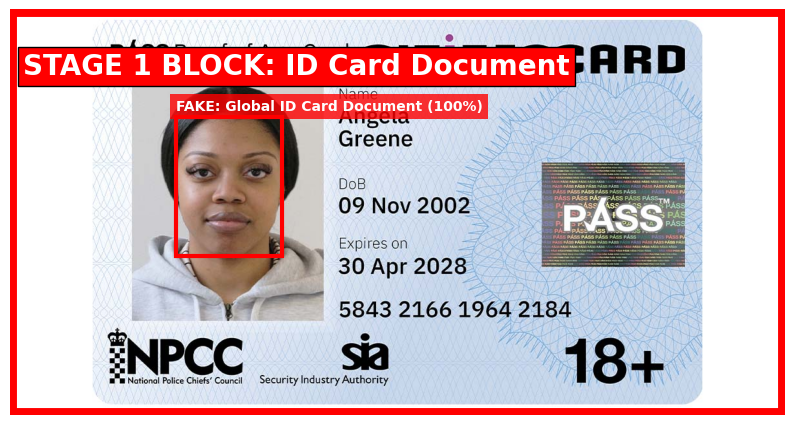

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from google.colab import files

print(" Loading Brain...")
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# --- 3. UPDATED DEFINITIONS (Webcam Fix) ---

# STAGE 1: GLOBAL SCENE CHECK
scene_real = {
    "a natural photo of a scene": "Real Environment",
    "a picture of people in a room": "Real Scene",
    # NEW PROMPTS TO FIX YOUR ERROR:
    "a webcam photo taken on a laptop": "Webcam Photo",
    "a low light indoor photo with noise": "Low Light Photo"
}

scene_fake = {
    # 1. ALBUMS / PRINTS
    "a photo of an open photo album": "Photo Album",
    "a pile of printed photographs": "Printed Photos",

    # 2. ID CARDS
    "an identity card on a table": "ID Card Document",

    # 3. SCREENS (Made stricter)
    "a photo of a mobile phone showing an app": "Phone Screen",
    "visible software buttons and status bars": "App UI",
    "a screenshot of a text conversation": "Chat Screenshot"
}

# STAGE 2: FACE CHECK
face_real = {
    "a real living person": "Real Person",
    "a clear selfie of a human": "Selfie",
    "a person with glasses": "Glasses",
    "a grainy webcam selfie": "Webcam Face"
}

face_fake = {
    "a face inside a rectangular ID card frame": "ID Card Portrait",
    "a face printed on a glossy paper page": "Album/Print",
    "a face displayed on a pixelated screen": "Screen Display",
    "halftone dots from a printed image": "Printed Texture",
    "warped AI generated facial features": "AI Distortion"
}

def get_verdict(image, real_dict, fake_dict):
    r_keys = list(real_dict.keys())
    f_keys = list(fake_dict.keys())
    all_prompts = r_keys + f_keys

    image_input = preprocess(image).unsqueeze(0).to(device)
    text_inputs = clip.tokenize(all_prompts).to(device)

    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)
        text_features = clip_model.encode_text(text_inputs)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        probs = (100.0 * image_features @ text_features.T).softmax(dim=-1).cpu().numpy()[0]

    r_score = np.sum(probs[:len(r_keys)])
    f_score = np.sum(probs[len(r_keys):])

    # STRICT THRESHOLD: Must be > 65% confident to call it Fake
    if f_score > 0.65:
        best_fake_idx = np.argmax(probs[len(r_keys):])
        reason = fake_dict[f_keys[best_fake_idx]]
        return "FAKE", f_score, reason
    else:
        return "REAL", r_score, "Real Person"

# --- 4. MAIN PIPELINE ---
print("\n--- UPLOAD IMAGE ---")
uploaded = files.upload()

if uploaded:
    img_path = list(uploaded.keys())[0]
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ----------------------------------------------
    # STAGE 1: WHOLE IMAGE CHECK
    # ----------------------------------------------
    print(">> Stage 1: Checking Full Image...")
    g_verdict, g_conf, g_reason = get_verdict(Image.fromarray(img_rgb), scene_real, scene_fake)

    global_fake = False
    if g_verdict == "FAKE":
        global_fake = True
        print(f"⚠️ BLOCKED BY STAGE 1: {g_reason} ({g_conf:.1%})")

    # ----------------------------------------------
    # STAGE 2: FACE + SURROUNDINGS CHECK
    # ----------------------------------------------
    try:
        faces = DeepFace.extract_faces(img_path=img_path, detector_backend='retinaface', enforce_detection=True, align=False)
    except:
        faces = []

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    ax = plt.gca()
    plt.axis("off")

    if global_fake:
        h, w, _ = img_rgb.shape
        rect = plt.Rectangle((0, 0), w, h, fill=False, color='red', linewidth=10)
        ax.add_patch(rect)
        ax.text(20, 100, f"STAGE 1 BLOCK: {g_reason}", fontsize=20, color='white', fontweight='bold', bbox=dict(facecolor='red'))

    for face in faces:
        fa = face['facial_area']
        x, y, w, h = fa['x'], fa['y'], fa['w'], fa['h']

        if global_fake:
            verdict = "FAKE"
            conf = g_conf
            reason = f"Global {g_reason}"
        else:
            # ZOOM OUT 2.5x TO SEE "SURROUNDINGS"
            h_img, w_img, _ = img_bgr.shape
            center_x, center_y = x + w/2, y + h/2
            new_w, new_h = w * 2.5, h * 2.5

            x1 = max(0, int(center_x - new_w/2))
            y1 = max(0, int(center_y - new_h/2))
            x2 = min(w_img, int(center_x + new_w/2))
            y2 = min(h_img, int(center_y + new_h/2))

            face_crop = img_rgb[y1:y2, x1:x2]
            if face_crop.size == 0: continue

            verdict, conf, reason = get_verdict(Image.fromarray(face_crop), face_real, face_fake)

        color = 'lime' if verdict == "REAL" else 'red'
        rect = plt.Rectangle((x, y), w, h, fill=False, color=color, linewidth=3)
        ax.add_patch(rect)

        text = f"{verdict}: {reason} ({conf:.0%})"
        ax.text(x, y-10, text, fontsize=10, color='white', fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.8, edgecolor='none'))

        if not global_fake:
             debug_rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='blue', linewidth=1, linestyle='--')
             ax.add_patch(debug_rect)

    plt.show()

video

In [12]:
import os
import sys
import subprocess
import shutil
import cv2
import numpy as np
import torch
import clip
from PIL import Image
from google.colab import files
from IPython.display import HTML, display

# --- 1. SETUP & INSTALL ---
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])

print(" Loading Visual AI...")
try:
    from deepface import DeepFace
except ImportError:
    install("deepface")
    install("tf-keras")
    install("opencv-python-headless")
    from deepface import DeepFace

try:
    import clip
except ImportError:
    install("ftfy")
    install("regex")
    install("git+https://github.com/openai/CLIP.git")

# --- 2. LOAD MODELS ---
print(" Loading Models...")
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# --- 3. PROMPTS (The "Brain") ---
scene_real = {
    "a natural photo of a person": "Real Person",
    "a webcam selfie": "Webcam Feed"
}
scene_fake = {
    "a photo of a printed picture": "Printed Photo",
    "a photo of a mobile phone screen": "Phone Screen",
    "a digital display showing a face": "Digital Display",
    "a hand holding a picture": "Holding Photo",
    "pixelated screen texture": "Screen Pixels"
}

face_real = {"a real human face": "Real Skin"}
face_fake = {
    "a printed face on paper": "Printed Face",
    "a face on a screen": "Screen Face",
    "a warped paper face": "Warped Paper"
}

# --- 4. HELPER FUNCTIONS ---
def get_clip_verdict(image, real_dict, fake_dict):
    # Prepare Inputs
    r_keys = list(real_dict.keys())
    f_keys = list(fake_dict.keys())
    all_prompts = r_keys + f_keys

    image_input = preprocess(image).unsqueeze(0).to(device)
    text_inputs = clip.tokenize(all_prompts).to(device)

    # Run AI
    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)
        text_features = clip_model.encode_text(text_inputs)
        probs = (100.0 * image_features @ text_features.T).softmax(dim=-1).cpu().numpy()[0]

    # Calculate Scores
    fake_prob = np.sum(probs[len(r_keys):])

    if fake_prob > 0.60: # Threshold
        best_fake_idx = np.argmax(probs[len(r_keys):])
        reason = fake_dict[f_keys[best_fake_idx]]
        return "FAKE", reason, (0, 0, 255) # Red
    else:
        return "REAL", "Real Person", (0, 255, 0) # Green

# --- 5. VIDEO PROCESSOR (WITH DRAWING) ---
def process_and_annotate(video_path):
    # 1. Setup Input
    safe_name = "input_video.mp4"
    output_name = "output_debug.mp4"
    if os.path.exists(safe_name): os.remove(safe_name)
    shutil.move(video_path, safe_name)

    cap = cv2.VideoCapture(safe_name)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    # 2. Setup Output Video Writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_name, fourcc, fps, (width, height))

    frame_count = 0
    print(">> Processing Video & Drawing Results...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Default: Assume undecided
        verdict = "Analyzing..."
        color = (255, 255, 0) # Cyan

        # OPTIMIZATION: Process every 3rd frame (Faster)
        # We reuse the last verdict for skipped frames to keep video smooth
        if frame_count % 3 == 0:
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(img_rgb)

            # A. GLOBAL SCENE CHECK
            g_verdict, g_reason, g_color = get_clip_verdict(pil_img, scene_real, scene_fake)

            if g_verdict == "FAKE":
                # If Scene is fake (e.g. holding a phone), mark whole frame
                cv2.rectangle(frame, (0, 0), (width, height), g_color, 10)
                cv2.putText(frame, f"GLOBAL BLOCK: {g_reason}", (50, 50),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, g_color, 3)
            else:
                # B. FACE CHECK (If scene is okay)
                try:
                    faces = DeepFace.extract_faces(img_path=frame, detector_backend='opencv',
                                                 enforce_detection=False, align=False)
                except: faces = []

                if faces:
                    face = faces[0]
                    x, y, w, h = face['facial_area']['x'], face['facial_area']['y'], face['facial_area']['w'], face['facial_area']['h']

                    # Crop Face for Analysis
                    face_crop = img_rgb[y:y+h, x:x+w]
                    if face_crop.size > 0:
                        f_verdict, f_reason, f_color = get_clip_verdict(Image.fromarray(face_crop), face_real, face_fake)

                        # Draw Box on Face
                        cv2.rectangle(frame, (x, y), (x+w, y+h), f_color, 3)
                        cv2.putText(frame, f"{f_verdict}: {f_reason}", (x, y-10),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, f_color, 2)

        # Write the annotated frame to the output video
        out.write(frame)
        frame_count += 1
        if frame_count % 30 == 0: print(f"   Processed {frame_count} frames...")

    cap.release()
    out.release()
    print(" Done! Video saved as 'output_debug.mp4'")
    return output_name

# --- 6. RUNNER ---
print("\n--- UPLOAD VIDEO TO ANALYZE ---")
uploaded = files.upload()

if uploaded:
    v_path = list(uploaded.keys())[0]
    out_file = process_and_annotate(v_path)

    # Download the result automatically
    files.download(out_file)

⚙️ Loading Visual AI...
 Loading Models...

--- UPLOAD VIDEO TO ANALYZE ---


Saving Firefly A man approaches the camera, his face illuminated by the dim light. He stops and pulls out a (1).mp4 to Firefly A man approaches the camera, his face illuminated by the dim light. He stops and pulls out a (1).mp4
>> Processing Video & Drawing Results...
   Processed 30 frames...
   Processed 60 frames...
   Processed 90 frames...
   Processed 120 frames...
   Processed 150 frames...
   Processed 180 frames...
 Done! Video saved as 'output_debug.mp4'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Identifying the person

In [7]:
import os
import sys
import subprocess
import shutil
import cv2
import numpy as np
import torch
import clip
from PIL import Image
from google.colab import files

# --- 1. SETUP ---
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])

print("⚙️ Loading AI Modules...")
try:
    from deepface import DeepFace
except ImportError:
    install("deepface")
    install("tf-keras")
    install("opencv-python-headless")
    from deepface import DeepFace

try:
    import clip
except ImportError:
    install("ftfy")
    install("regex")
    install("git+https://github.com/openai/CLIP.git")
    import clip

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# --- 2. CONFIG ---
# ArcFace cosine distance threshold (Lower = Stricter)
THRESHOLD = 0.60
# CLIP Spoof Sensitivity (Lower = More suspicious/Stricter)
SPOOF_THRESHOLD = 0.45

# --- 3. PROMPTS ---
scene_real = {
    "a natural photo of a person in a room": "Real Environment",
    "a person looking at a camera": "Live User"
}
scene_fake = {
    "a photo of a printed picture": "Printed Photo",
    "a person holding a piece of paper up": "Paper Attack",
    "a hand holding an ID card": "ID Card Detected",
    "a photo of a phone screen": "Digital Attack"
}

face_real = {"a real human face with natural skin texture": "Real Skin"}
face_fake = {
    "a face printed on a plastic card": "Plastic ID",
    "a picture of a picture": "Replay Attack",
    "a face on a paper document": "Document Spoof",
    "a face with camera flash reflection on plastic": "Card Glare",
    "the edges of a passport or ID card": "ID Border"
}

# --- 4. HELPER FUNCTIONS ---
def get_clip_verdict(image, real_dict, fake_dict):
    r_keys, f_keys = list(real_dict.keys()), list(fake_dict.keys())
    all_prompts = r_keys + f_keys

    image_input = preprocess(image).unsqueeze(0).to(device)
    text_inputs = clip.tokenize(all_prompts).to(device)

    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)
        text_features = clip_model.encode_text(text_inputs)
        probs = (100.0 * image_features @ text_features.T).softmax(dim=-1).cpu().numpy()[0]

    fake_prob = np.sum(probs[len(r_keys):])
    if fake_prob > SPOOF_THRESHOLD:
        best_fake_idx = np.argmax(probs[len(r_keys):])
        return "FAKE", fake_dict[f_keys[best_fake_idx]]
    return "REAL", "Real Person"

def find_cosine_distance(source_representation, test_representation):
    a = np.matmul(np.transpose(source_representation), test_representation)
    b = np.sum(np.multiply(source_representation, source_representation))
    c = np.sum(np.multiply(test_representation, test_representation))
    return 1 - (a / (np.sqrt(b) * np.sqrt(c)))

# --- 5. MAIN PROCESSOR ---
def run_secure_access(video_path, ref_embedding):
    safe_name = "input_vid.mp4"
    output_name = "output_secure_access.mp4"
    if os.path.exists(safe_name): os.remove(safe_name)
    shutil.move(video_path, safe_name)

    cap = cv2.VideoCapture(safe_name)
    width, height = int(cap.get(3)), int(cap.get(4))
    fps = int(cap.get(5))
    out = cv2.VideoWriter(output_name, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    frame_count = 0
    print(">> Processing Video Security Check...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Process every 3rd frame for speed
        if frame_count % 3 == 0:
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # 1. Global Scene Check (Whole Frame)
            g_verdict, g_reason = get_clip_verdict(Image.fromarray(img_rgb), scene_real, scene_fake)

            if g_verdict == "FAKE":
                cv2.rectangle(frame, (0, 0), (width, height), (0, 0, 255), 10)
                cv2.putText(frame, f"SPOOF DETECTED: {g_reason}", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
            else:
                try:
                    # Face detection
                    faces = DeepFace.extract_faces(frame, detector_backend='opencv', enforce_detection=False, align=False)
                except: faces = []

                for face in faces:
                    x, y, w, h = face['facial_area']['x'], face['facial_area']['y'], face['facial_area']['w'], face['facial_area']['h']

                    # --- ADD PADDING FOR CLIP ---
                    # This allows the AI to see the ID card edges or fingers holding it
                    pad_w, pad_h = int(w * 0.3), int(h * 0.3)
                    x1, y1 = max(0, x - pad_w), max(0, y - pad_h)
                    x2, y2 = min(width, x + w + pad_w), min(height, y + h + pad_h)

                    context_crop = img_rgb[y1:y2, x1:x2] # The "Zoomed Out" crop
                    face_crop = img_rgb[y:y+h, x:x+w]       # The "Tight" crop

                    if context_crop.size > 0:
                        # 2. Liveness Check on the Context Crop
                        f_verdict, f_reason = get_clip_verdict(Image.fromarray(context_crop), face_real, face_fake)

                        box_color = (0, 0, 255)
                        label = f"FAKE: {f_reason}"

                        if f_verdict == "REAL":
                            # 3. Identity Check (Only if Liveness passes)
                            try:
                                target_objs = DeepFace.represent(face_crop, model_name="ArcFace", enforce_detection=False)
                                target_embed = target_objs[0]["embedding"]
                                distance = find_cosine_distance(ref_embedding, target_embed)

                                if distance < THRESHOLD:
                                    box_color = (0, 255, 0) # Success
                                    label = f"ACCESS GRANTED ({distance:.2f})"
                                else:
                                    box_color = (255, 0, 0) # Wrong Person
                                    label = f"ACCESS DENIED ({distance:.2f})"
                            except:
                                label = "Encoding Error"

                        cv2.rectangle(frame, (x, y), (x+w, y+h), box_color, 3)
                        cv2.putText(frame, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

        out.write(frame)
        frame_count += 1
        if frame_count % 30 == 0: print(f"   Checked {frame_count} frames...")

    cap.release()
    out.release()
    return output_name

# --- 6. EXECUTION ---
print("\n--- STEP 1: UPLOAD REFERENCE PHOTO (The Owner) ---")
upl_ref = files.upload()
if not upl_ref:
    print(" No file uploaded.")
else:
    ref_filename = list(upl_ref.keys())[0]

    print(">> Generating Reference ID...")
    try:
        ref_objs = DeepFace.represent(ref_filename, model_name="ArcFace", enforce_detection=True)
        reference_embedding = ref_objs[0]["embedding"]
        print(" Reference ID Created.")

        print("\n--- STEP 2: UPLOAD VIDEO TO TEST ---")
        upl_vid = files.upload()
        if not upl_vid:
            print(" No video uploaded.")
        else:
            vid_filename = list(upl_vid.keys())[0]
            result_video = run_secure_access(vid_filename, reference_embedding)
            print("\n Processing complete. Downloading result...")
            files.download(result_video)

    except Exception as e:
        print(f" Error: {e}")

⚙️ Loading AI Modules...


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 167MiB/s]



--- STEP 1: UPLOAD REFERENCE PHOTO (The Owner) ---


Saving Screenshot 2026-05-16 133816.png to Screenshot 2026-05-16 133816.png
>> Generating Reference ID...
26-05-16 08:34:19 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:01<00:00, 125MB/s]


 Reference ID Created.

--- STEP 2: UPLOAD VIDEO TO TEST ---


Saving Firefly generate a man in a office coming near and then showing a printed image of a women 226950.mp4 to Firefly generate a man in a office coming near and then showing a printed image of a women 226950.mp4
>> Processing Video Security Check...
   Checked 30 frames...
   Checked 60 frames...
   Checked 90 frames...
   Checked 120 frames...
   Checked 150 frames...
   Checked 180 frames...

 Processing complete. Downloading result...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>